# 04_New_Models_Comparison.ipynb

This notebook implements and evaluates two new alternative models to address the J-shaped distribution of star ratings:
1. **Ordinal Logistic Regression** (Proportional Odds Model)
2. **Binary Logistic Regression** (5-stars vs. 1-4 stars)

We use the same 5-fold cross-validation setup (random_state=42) and GLASSO-selected interactions as the existing linear models to ensure comparability.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path for imports
sys.path.append(os.path.abspath('..'))

from src.modeling_alternative import run_ordinal_cv, run_binary_cv, get_existing_results
from src.modeling import prepare_raw_modeling_data

# 1. Load Local Data
data_path = '../data/Seminar_Amazon_Results_FULL.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Local data loaded: {len(df)} rows.")
    
    # Parse stringified lists of tuples if they are strings
    if isinstance(df['aspect_sentiments'].iloc[0], str):
        print("Parsing aspect_sentiments column...")
        df['aspect_sentiments'] = df['aspect_sentiments'].apply(ast.literal_eval)
else:
    print(f"❌ Error: File not found at {data_path}. Please ensure the CSV is in the './data/' folder.")

c:\Users\Nativ\Documents\seminar\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Local data loaded: 701528 rows.
Parsing aspect_sentiments column...


## Part 1: Ordinal Logistic Regression
We treat star ratings as ordered categories.

In [2]:
print("Running Ordinal Logistic Regression CV...")
ordinal_results = run_ordinal_cv(df)

# Save results
with open('../model_ordinal_results.pkl', 'wb') as f:
    pickle.dump(ordinal_results, f)

def summarize_ordinal(res_list):
    df_res = pd.DataFrame(res_list)
    # Exclude confusion matrix from mean calculation
    return df_res.drop(columns=['confusion_matrix'], errors='ignore').mean()

ord_add_summary = summarize_ordinal(ordinal_results['additive'])
ord_int_summary = summarize_ordinal(ordinal_results['interaction'])

print("\nOrdinal Additive Summary:")
print(ord_add_summary)
print("\nOrdinal Interaction Summary:")
print(ord_int_summary)

2026-06-04 14:35:01,750 - INFO - Pivoting raw sentiment features...


Running Ordinal Logistic Regression CV...


2026-06-04 14:35:02,751 - INFO - Sparsity Filter: Dropped 379395 empty reviews. Remaining valid reviews: 322133
2026-06-04 14:35:02,751 - INFO - Starting Ordinal Logistic Regression Cross-Validation...
2026-06-04 14:35:02,768 - INFO - Processing Fold 1/5...
2026-06-04 14:36:45,557 - INFO - DEBUG: Sample Additive Predictions (First 10): [np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(1), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(1)]
2026-06-04 14:36:45,557 - INFO - DEBUG: Sample True Labels (First 10):      [5, 5, 3, 5, 1, 5, 5, 4, 5, 4]
2026-06-04 14:36:45,824 - INFO - Starting EBIC selection for 7 aspects...
2026-06-04 14:36:45,988 - INFO - Selected lambda: 0.001000
2026-06-04 14:36:45,990 - INFO - Generating interaction features from 11 network edges...
2026-06-04 14:36:46,007 - INFO - Generating interaction features from 11 network edges...
2026-06-04 14:43:29,545 - INFO - Processing Fold 2/5...
2026-06-04 14:45:04,813 - INFO - Starting EBIC selectio


Ordinal Additive Summary:
log_likelihood   -270355.407622
aic               540732.815243
bic               540847.870582
rps                    0.131469
f1_macro               0.262157
dtype: float64

Ordinal Interaction Summary:
log_likelihood   -270248.686895
aic               540541.373789
bic               540771.484466
rps                    0.131446
f1_macro               0.262275
dtype: float64


In [3]:
# Additional Ordinal Metrics
print(f"Ordinal Additive - Avg BIC: {ord_add_summary['bic']:.2f}, Avg Macro-F1: {ord_add_summary['f1_macro']:.4f}")
print(f"Ordinal Interaction - Avg BIC: {ord_int_summary['bic']:.2f}, Avg Macro-F1: {ord_int_summary['f1_macro']:.4f}")

Ordinal Additive - Avg BIC: 540847.87, Avg Macro-F1: 0.2622
Ordinal Interaction - Avg BIC: 540771.48, Avg Macro-F1: 0.2623


### Ordinal Confusion Matrices

Ordinal Confusion Matrices (Aggregated across 5 folds):


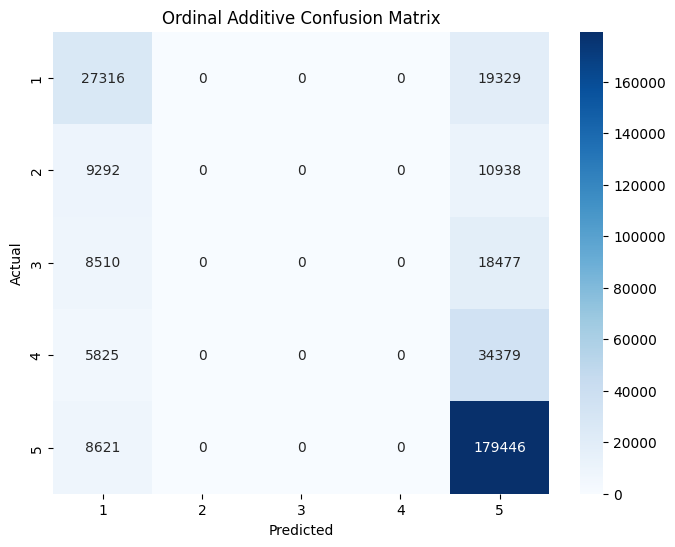

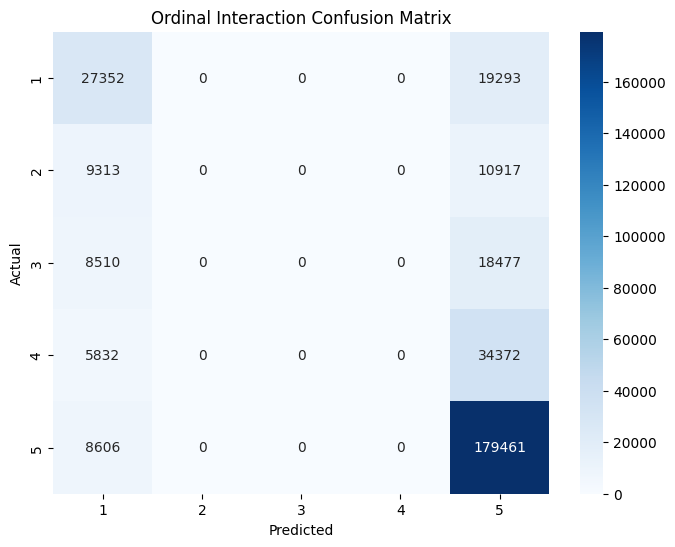

In [4]:
def plot_aggregated_cm(results_list, title, labels=[1,2,3,4,5]):
    # Aggregate confusion matrices across folds
    if 'confusion_matrix' not in results_list[0]:
        print(f"Skipping {title}: confusion_matrix not found. Please restart kernel and re-run CV.")
        return
    
    cm_sum = np.zeros_like(results_list[0]['confusion_matrix'])
    for res in results_list:
        cm_sum += res['confusion_matrix']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_sum, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

print("Ordinal Confusion Matrices (Aggregated across 5 folds):")
plot_aggregated_cm(ordinal_results['additive'], "Ordinal Additive Confusion Matrix")
plot_aggregated_cm(ordinal_results['interaction'], "Ordinal Interaction Confusion Matrix")

## Part 2: Binary Logistic Regression
We predict whether a review is a 5-star review (1) or not (0).

In [5]:
print("Running Binary Logistic Regression CV...")
binary_results = run_binary_cv(df)

# Save results
with open('../model_binary_results.pkl', 'wb') as f:
    pickle.dump(binary_results, f)

def summarize_binary(res_list):
    df_res = pd.DataFrame(res_list)
    # Exclude confusion matrix from mean calculation
    return df_res.drop(columns=['confusion_matrix'], errors='ignore').mean()

bin_add_summary = summarize_binary(binary_results['additive'])
bin_int_summary = summarize_binary(binary_results['interaction'])

print("\nBinary Additive Summary:")
print(bin_add_summary)
print("\nBinary Interaction Summary:")
print(bin_int_summary)

2026-06-04 15:14:40,844 - INFO - Pivoting raw sentiment features...


Running Binary Logistic Regression CV...


2026-06-04 15:14:41,834 - INFO - Sparsity Filter: Dropped 379395 empty reviews. Remaining valid reviews: 322133
2026-06-04 15:14:41,838 - INFO - Starting Binary Logistic Regression Cross-Validation...
2026-06-04 15:14:41,845 - INFO - Processing Fold 1/5...
2026-06-04 15:14:42,379 - INFO - Starting EBIC selection for 7 aspects...
2026-06-04 15:14:42,524 - INFO - Selected lambda: 0.001000
2026-06-04 15:14:42,524 - INFO - Generating interaction features from 11 network edges...
2026-06-04 15:14:42,540 - INFO - Generating interaction features from 11 network edges...
2026-06-04 15:14:43,184 - INFO - Processing Fold 2/5...
2026-06-04 15:14:43,774 - INFO - Starting EBIC selection for 7 aspects...
2026-06-04 15:14:43,925 - INFO - Selected lambda: 0.001000
2026-06-04 15:14:43,925 - INFO - Generating interaction features from 11 network edges...
2026-06-04 15:14:43,941 - INFO - Generating interaction features from 11 network edges...
2026-06-04 15:14:44,676 - INFO - Processing Fold 3/5...
2026-


Binary Additive Summary:
accuracy         0.747188
roc_auc          0.795378
f1               0.794367
bic         275641.092510
dtype: float64

Binary Interaction Summary:
accuracy         0.745748
roc_auc          0.794339
f1               0.794039
bic         275089.562440
dtype: float64


In [6]:
# Additional Binary Metrics
print(f"Binary Additive - Avg BIC: {bin_add_summary['bic']:.2f}, Avg F1: {bin_add_summary['f1']:.4f}")
print(f"Binary Interaction - Avg BIC: {bin_int_summary['bic']:.2f}, Avg F1: {bin_int_summary['f1']:.4f}")

Binary Additive - Avg BIC: 275641.09, Avg F1: 0.7944
Binary Interaction - Avg BIC: 275089.56, Avg F1: 0.7940


### Binary Confusion Matrices

Binary Confusion Matrices (Aggregated across 5 folds):


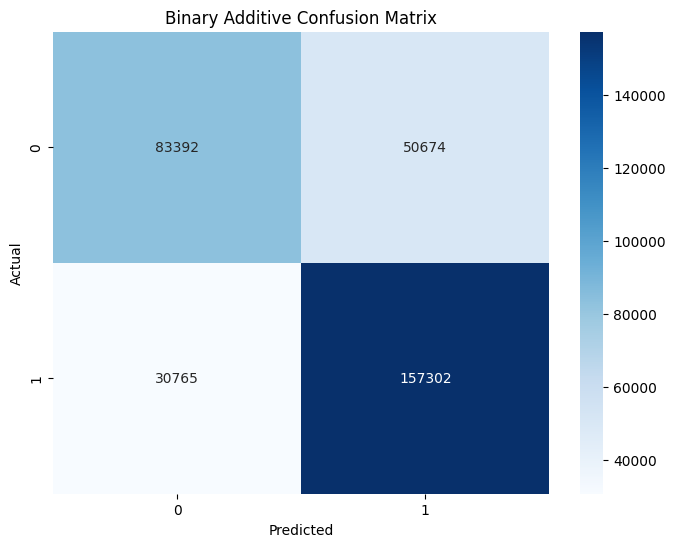

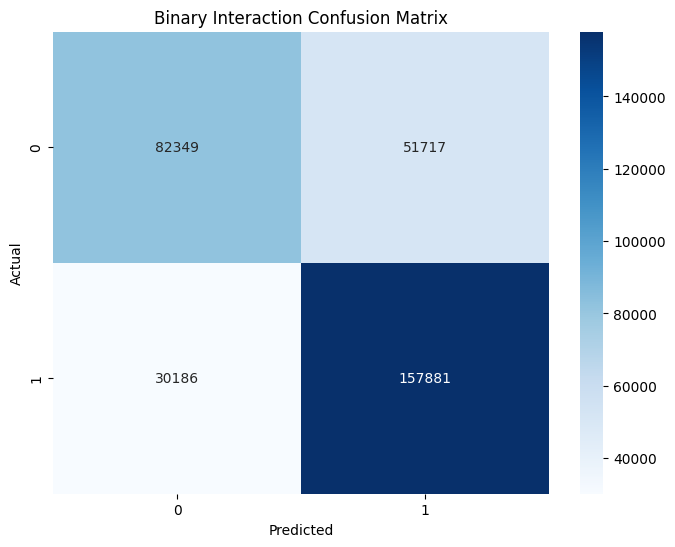

In [7]:
print("Binary Confusion Matrices (Aggregated across 5 folds):")
plot_aggregated_cm(binary_results['additive'], "Binary Additive Confusion Matrix", labels=[0, 1])
plot_aggregated_cm(binary_results['interaction'], "Binary Interaction Confusion Matrix", labels=[0, 1])

## Part 3: Final Comparison Table
Consolidating all models.

In [8]:
existing = get_existing_results()

summary_data = []

# Linear Models
summary_data.append({
    'Model': 'Linear Additive',
    'Type': 'Continuous',
    'Metric 1 (RMSE/Acc)': existing['Linear Additive']['Avg RMSE'],
    'Metric 2 (AdjR2/AUC)': existing['Linear Additive']['Avg Adj R2'],
    'Complexity (BIC/AIC)': existing['Linear Additive']['Full BIC']
})
summary_data.append({
    'Model': 'Linear Interaction',
    'Type': 'Continuous',
    'Metric 1 (RMSE/Acc)': existing['Linear Interaction']['Avg RMSE'],
    'Metric 2 (AdjR2/AUC)': existing['Linear Interaction']['Avg Adj R2'],
    'Complexity (BIC/AIC)': existing['Linear Interaction']['Full BIC']
})

# Ordinal Models
summary_data.append({
    'Model': 'Ordinal Additive',
    'Type': 'Categorical',
    'Metric 1 (RMSE/Acc)': ord_add_summary['rps'], # Using RPS for Metric 1
    'Metric 2 (AdjR2/AUC)': ord_add_summary['log_likelihood'],
    'Complexity (BIC/AIC)': ord_add_summary['aic']
})
summary_data.append({
    'Model': 'Ordinal Interaction',
    'Type': 'Categorical',
    'Metric 1 (RMSE/Acc)': ord_int_summary['rps'],
    'Metric 2 (AdjR2/AUC)': ord_int_summary['log_likelihood'],
    'Complexity (BIC/AIC)': ord_int_summary['aic']
})

# Binary Models
summary_data.append({
    'Model': 'Binary Additive',
    'Type': 'Binary',
    'Metric 1 (RMSE/Acc)': bin_add_summary['accuracy'],
    'Metric 2 (AdjR2/AUC)': bin_add_summary['roc_auc'],
    'Complexity (BIC/AIC)': bin_add_summary['f1']
})
summary_data.append({
    'Model': 'Binary Interaction',
    'Type': 'Binary',
    'Metric 1 (RMSE/Acc)': bin_int_summary['accuracy'],
    'Metric 2 (AdjR2/AUC)': bin_int_summary['roc_auc'],
    'Complexity (BIC/AIC)': bin_int_summary['f1']
})

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*90)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)

print("\nNote: Metrics vary by model type. Linear uses RMSE/AdjR2/BIC. Ordinal uses RPS/LL/AIC. Binary uses Acc/AUC/F1.")


FINAL MODEL COMPARISON SUMMARY
              Model        Type  Metric 1 (RMSE/Acc)  Metric 2 (AdjR2/AUC)  Complexity (BIC/AIC)
    Linear Additive  Continuous             1.214400              0.335100          1.039391e+06
 Linear Interaction  Continuous             1.203400              0.347000          1.032536e+06
   Ordinal Additive Categorical             0.131469        -270355.407622          5.407328e+05
Ordinal Interaction Categorical             0.131446        -270248.686895          5.405414e+05
    Binary Additive      Binary             0.747188              0.795378          7.943675e-01
 Binary Interaction      Binary             0.745748              0.794339          7.940393e-01

Note: Metrics vary by model type. Linear uses RMSE/AdjR2/BIC. Ordinal uses RPS/LL/AIC. Binary uses Acc/AUC/F1.


## Enhanced Comparison Table
Including BIC and F1 (Macro for Categorical/Continuous where applicable).

In [9]:
enhanced_data = []

# Linear (Approximate F1 not direct, keeping BIC)
enhanced_data.append({
    'Model': 'Linear Additive',
    'BIC': existing['Linear Additive']['Full BIC'],
    'F1/Macro-F1': np.nan
})
enhanced_data.append({
    'Model': 'Linear Interaction',
    'BIC': existing['Linear Interaction']['Full BIC'],
    'F1/Macro-F1': np.nan
})

# Ordinal
enhanced_data.append({
    'Model': 'Ordinal Additive',
    'BIC': ord_add_summary['bic'],
    'F1/Macro-F1': ord_add_summary['f1_macro']
})
enhanced_data.append({
    'Model': 'Ordinal Interaction',
    'BIC': ord_int_summary['bic'],
    'F1/Macro-F1': ord_int_summary['f1_macro']
})

# Binary
enhanced_data.append({
    'Model': 'Binary Additive',
    'BIC': bin_add_summary['bic'],
    'F1/Macro-F1': bin_add_summary['f1']
})
enhanced_data.append({
    'Model': 'Binary Interaction',
    'BIC': bin_int_summary['bic'],
    'F1/Macro-F1': bin_int_summary['f1']
})

enhanced_df = pd.DataFrame(enhanced_data)
print("\nENHANCED MODEL COMPARISON (BIC & F1)")
print(enhanced_df.to_string(index=False))


ENHANCED MODEL COMPARISON (BIC & F1)
              Model          BIC  F1/Macro-F1
    Linear Additive 1.039391e+06          NaN
 Linear Interaction 1.032536e+06          NaN
   Ordinal Additive 5.408479e+05     0.262157
Ordinal Interaction 5.407715e+05     0.262275
    Binary Additive 2.756411e+05     0.794367
 Binary Interaction 2.750896e+05     0.794039
